# 1 — Calibration and exploratory analysis

This notebook covers the first half of the pipeline:

1. **Clean a real retail transaction dataset** (UCI Online Retail II, ~1M lines) and audit every row removed.
2. **Estimate the demand parameters** the simulator needs — popularity skew, basket size, seasonality.
3. **Explore the generated warehouse data** and check it inherited those properties.

The warehouse geometry has to be synthetic; no public dataset contains real slot layouts. The demand side does not, and estimating it from data rather than inventing it is what separates a simulation you can argue for from one you cannot.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CONFIG, PROCESSED_DIR
from src.calibration.fit_parameters import load_calibration
from src.simulation.generate import load_dataset
from src.policies.slotting import abc_xyz_classes

plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.width', 160)

## 1. Cleaning the real transactions

The raw file is genuinely messy, which is the point — it exercises the same judgement any real project needs. Each step below records how many rows it removed, so the cleaning is auditable rather than a black box.

In [2]:
audit = pd.read_csv(PROCESSED_DIR / 'cleaning_audit.csv')
audit['pct_of_raw'] = (100 * audit['rows_removed'] / audit['rows_remaining'].iloc[0]).round(2)
audit

,step,rows_removed,rows_remaining,pct_of_raw
0,raw,0,1067371,0.00
1,drop rows with missing key fields,0,1067371,0.00
2,drop cancellation invoices,19494,1047877,1.83
3,drop non-product stock codes,4583,1043294,0.43
4,drop malformed stock codes,301,1042993,0.03
5,drop out-of-range quantities (incl. returns),3461,1039532,0.32
6,drop out-of-range prices,2686,1036846,0.25
7,drop exact duplicate rows,33663,1003183,3.15
8,drop unparseable timestamps,0,1003183,0.00


Cancellations (invoices prefixed `C`) and exact duplicates dominate the removals. Note what is *not* removed: nothing is dropped for being an outlier in demand, because a genuinely huge wholesale order is exactly the kind of event a warehouse has to cope with.

In [3]:
calibration = load_calibration()
print(calibration.summary())

source              : real (UCI Online Retail II)
transactions        : 1,003,183
distinct products   : 4,706
date range          : 2009-12-01 .. 2011-12-09
zipf exponent       : 1.789
top-20% demand share: 76.9%
lines per order     : mean 25.1
units per line      : mean 10.8
weekday factors     : 1.30, 1.21, 1.16, 1.37, 1.00, 0.32, 0.65



## 2. What the real data says

### Popularity is extremely skewed

This is the single most important fact for the whole project: if demand were uniform across products, slot assignment would not matter.

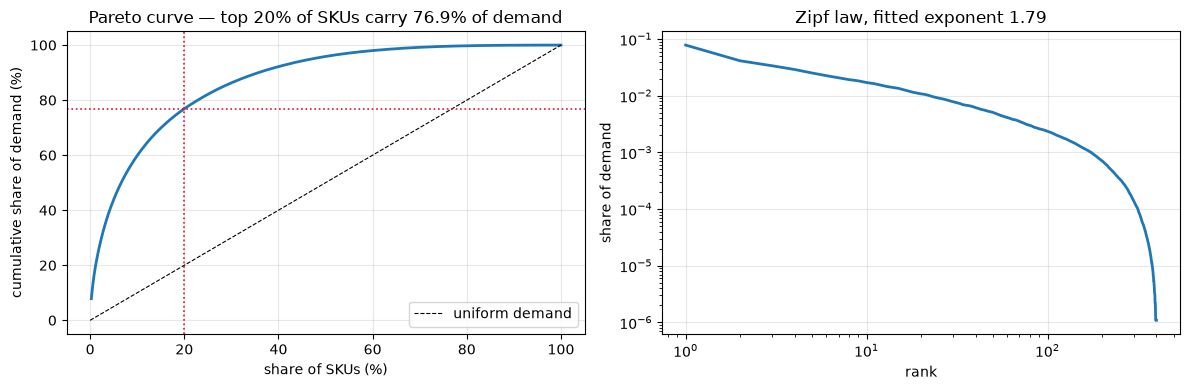

In [4]:
curve = np.array(calibration.popularity_curve)
cum = np.cumsum(curve) / curve.sum()
share_of_skus = np.arange(1, curve.size + 1) / curve.size

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(share_of_skus * 100, cum * 100, lw=2)
axes[0].plot([0, 100], [0, 100], 'k--', lw=0.8, label='uniform demand')
axes[0].axvline(20, color='crimson', ls=':', lw=1.2)
axes[0].axhline(calibration.top20_demand_share * 100, color='crimson', ls=':', lw=1.2)
axes[0].set_xlabel('share of SKUs (%)'); axes[0].set_ylabel('cumulative share of demand (%)')
axes[0].set_title(f'Pareto curve — top 20% of SKUs carry {calibration.top20_demand_share:.1%} of demand')
axes[0].legend()

ranks = np.arange(1, curve.size + 1)
axes[1].loglog(ranks, curve, lw=2)
axes[1].set_xlabel('rank'); axes[1].set_ylabel('share of demand')
axes[1].set_title(f'Zipf law, fitted exponent {calibration.zipf_exponent:.2f}')
plt.tight_layout(); plt.show()

### Seasonality — and a genuinely interesting real-world pattern

The weekday and month multipliers below are **estimated from the real data, not chosen**. Two things stand out, and neither is what a naive guess would have produced.

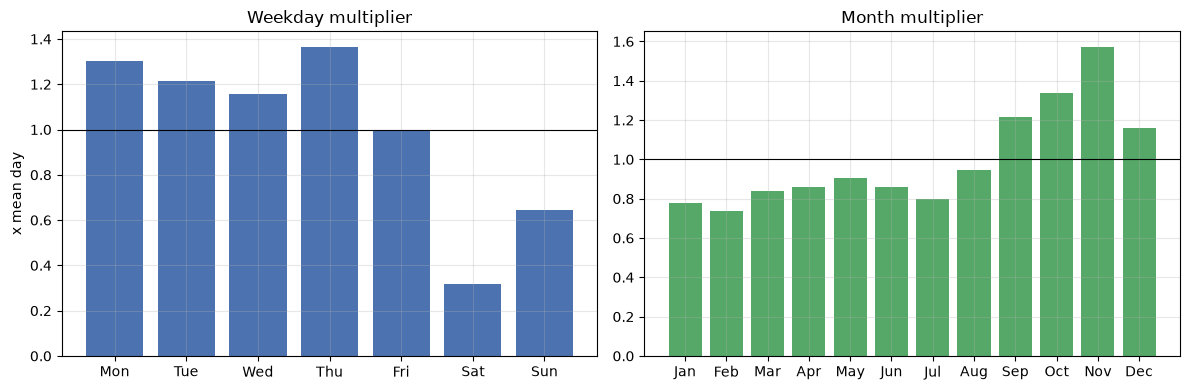

Saturday multiplier : 0.32
November multiplier : 1.57
December multiplier : 1.16


In [5]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(days, calibration.weekday_factors, color='#4C72B0')
axes[0].axhline(1.0, color='k', lw=0.8)
axes[0].set_title('Weekday multiplier'); axes[0].set_ylabel('x mean day')

axes[1].bar(months, calibration.month_factors, color='#55A868')
axes[1].axhline(1.0, color='k', lw=0.8)
axes[1].set_title('Month multiplier')
plt.tight_layout(); plt.show()

print('Saturday multiplier :', round(calibration.weekday_factors[5], 2))
print('November multiplier :', round(calibration.month_factors[10], 2))
print('December multiplier :', round(calibration.month_factors[11], 2))

**Saturday nearly stops.** The multiplier is about 0.3 — this is a wholesale operation, and wholesalers do not trade at the weekend the way shops do.

**The peak is November, not December.** A retail dataset would peak in December. This one supplies *shops*, so its own peak lands one to two months earlier — the stock has to be on the shelves before Christmas, not during it. December is already declining.

Neither of these would have been guessed. This is exactly the return on calibrating against real data instead of writing down plausible-looking constants.

### Basket structure

Lines per order drives tour length, and units per line drives handling time. Both are stored as empirical quantile grids rather than fitted distributions: real basket sizes are lumpy and long-tailed, and pretending they are negative-binomial would smooth away the tail that actually stresses the warehouse.

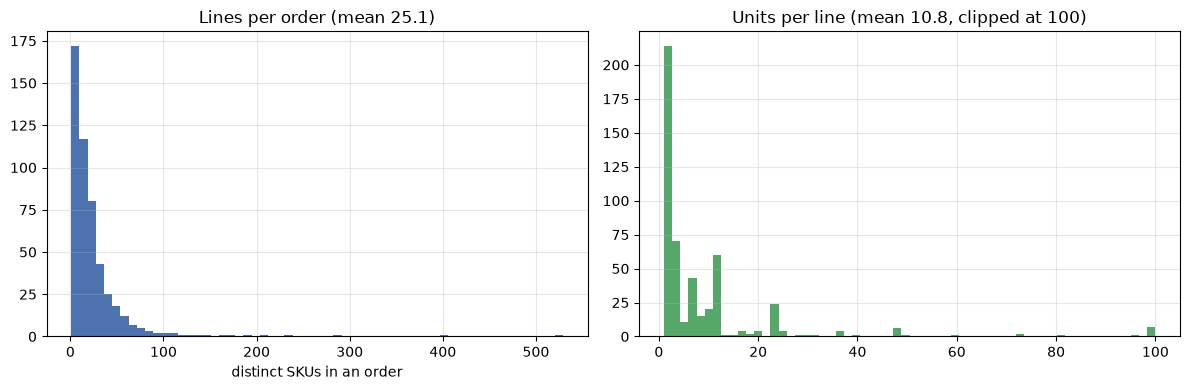

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(calibration.lines_per_order_quantiles, bins=60, color='#4C72B0')
axes[0].set_title(f'Lines per order (mean {calibration.lines_per_order_mean:.1f})')
axes[0].set_xlabel('distinct SKUs in an order')
axes[1].hist(np.clip(calibration.units_per_line_quantiles, 0, 100), bins=60, color='#55A868')
axes[1].set_title(f'Units per line (mean {calibration.units_per_line_mean:.1f}, clipped at 100)')
plt.tight_layout(); plt.show()

## 3. The generated warehouse

Now the synthetic side. The question to ask of every chart below is whether the generated data actually inherited the properties estimated above.

In [7]:
tables = load_dataset()
for name, frame in tables.items():
    if not name.startswith('_'):
        print(f'{name:<20} {len(frame):>9,} rows x {frame.shape[1]:>2} cols')
tables['sku_catalog'].head()

warehouse_slots          2,880 rows x 12 cols
sku_catalog              2,400 rows x  9 cols
daily_demand         1,296,000 rows x  3 cols
orders                  21,087 rows x 14 cols
order_lines            483,458 rows x  3 cols
trucks                   2,172 rows x  9 cols
putaway_receipts        22,839 rows x  5 cols


,sku_id,category,is_cold,is_heavy,volume_l,weight_kg,unit_value,popularity,express_propensity
0,SKU0001,Beverage,True,False,1.00,5.38,51.37,0.000044,1.0
1,SKU0002,Apparel,False,False,0.93,0.47,11.35,0.001564,1.0
2,SKU0003,Beverage,True,False,0.50,11.77,23.15,0.000004,1.0
3,SKU0004,Food,True,False,1.45,0.38,67.48,0.000610,2.0
4,SKU0005,Electronics,False,False,1.01,10.33,27.70,0.001394,2.0


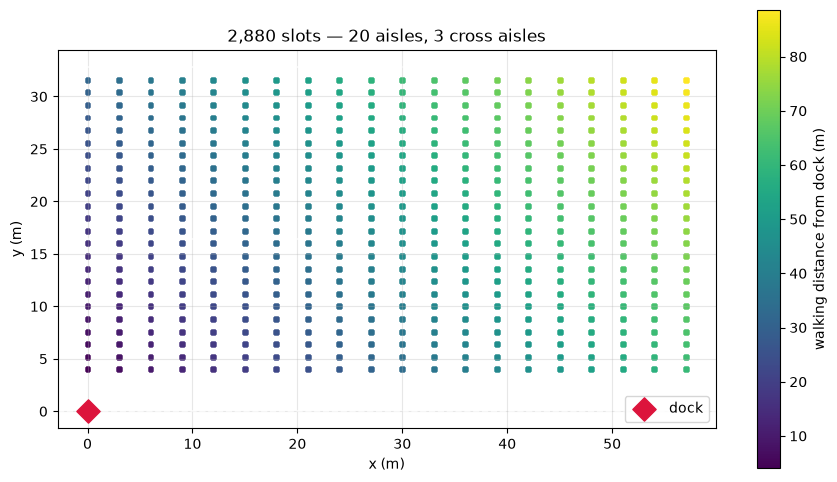

dock distance: min 4.0 m, median 46.3 m, max 88.6 m


In [8]:
slots = tables['warehouse_slots']
wh = CONFIG.warehouse

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(slots['x'], slots['y'], c=slots['dock_distance'], cmap='viridis', s=8, marker='s')
for y in wh.cross_aisle_ys:
    ax.axhline(y, color='white', lw=1.2, ls='--', alpha=0.8)
ax.scatter([wh.dock_x], [0], marker='D', s=140, color='crimson', zorder=5, label='dock')
plt.colorbar(sc, label='walking distance from dock (m)')
ax.set_aspect('equal'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.legend()
ax.set_title(f'{len(slots):,} slots — {wh.n_aisles} aisles, {wh.n_cross_aisles} cross aisles')
plt.tight_layout(); plt.show()

print('dock distance: min %.1f m, median %.1f m, max %.1f m' % (
    slots.dock_distance.min(), slots.dock_distance.median(), slots.dock_distance.max()))

The dashed lines are the cross aisles. Notice how the distance contours bend around them — a slot near the middle cross aisle is much closer than its raw y coordinate suggests. That effect is the entire reason routing optimisation has anything to do here (see notebook 2).

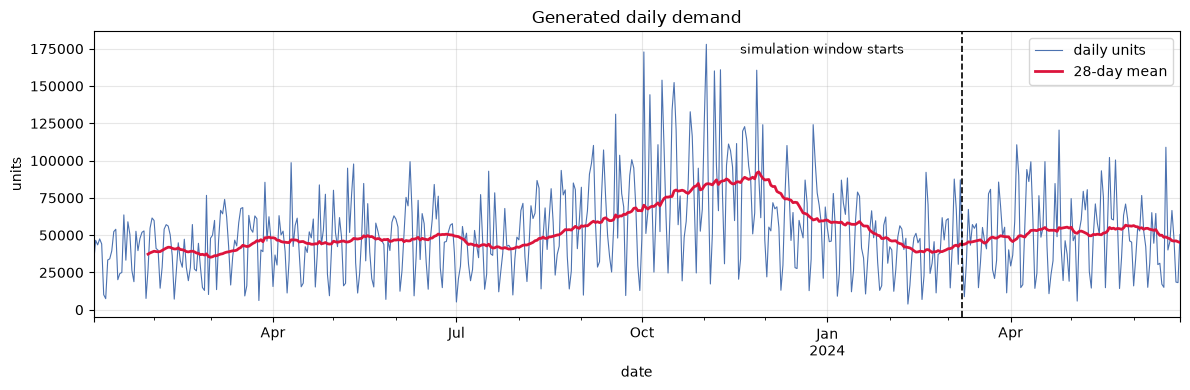

In [9]:
daily = tables['daily_demand'].copy()
daily['date'] = pd.to_datetime(daily['date'])
totals = daily.groupby('date')['demand'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
totals.plot(ax=ax, lw=0.8, color='#4C72B0', label='daily units')
totals.rolling(28).mean().plot(ax=ax, lw=2, color='crimson', label='28-day mean')
sim_start = pd.Timestamp(tables['_meta'].iloc[0]['start_date']) + pd.Timedelta(
    days=int(tables['_meta'].iloc[0]['window_start_day']))
ax.axvline(sim_start, color='k', ls='--', lw=1.2)
ax.annotate('simulation window starts', (sim_start, ax.get_ylim()[1] * 0.92),
            xytext=(-160, 0), textcoords='offset points', fontsize=9)
ax.set_title('Generated daily demand'); ax.set_ylabel('units'); ax.legend()
plt.tight_layout(); plt.show()

Everything to the left of the dashed line is available for training the demand model. Everything to the right is the simulated operation — and no model is allowed to see it.

In [10]:
# Did the generated data inherit the real weekday pattern?
generated_weekday = totals.groupby(totals.index.dayofweek).mean()
generated_weekday = generated_weekday / generated_weekday.mean()

comparison = pd.DataFrame({
    'calibrated (real data)': calibration.weekday_factors,
    'generated data': generated_weekday.to_numpy(),
}, index=days).round(3)
comparison

,calibrated (real data),generated data
Mon,1.301,1.293
Tue,1.213,1.202
Wed,1.156,1.179
Thu,1.366,1.361
Fri,1.000,0.987
Sat,0.319,0.295
Sun,0.646,0.684


## 4. ABC / XYZ segmentation

ABC splits products by volume, XYZ by how predictable their **weekly** demand is. Weekly, not daily: daily SKU demand is intermittent almost by construction, so a daily coefficient of variation puts nearly everything in class Z and the segmentation says nothing. Weekly is the bucket a replenishment planner actually works in.

In [11]:
classes = abc_xyz_classes(tables['daily_demand'], tables['sku_catalog'])
matrix = classes.groupby(['abc_class', 'xyz_class']).size().unstack(fill_value=0)
share = (classes.groupby('abc_class')['total_demand'].sum() / classes['total_demand'].sum() * 100).round(1)

print('SKU counts:'); print(matrix)
print('\nShare of total demand (%):'); print(share.to_string())

SKU counts:
xyz_class    X    Y     Z
abc_class                
A          157  390     0
B            0  284   292
C            0   17  1260

Share of total demand (%):
abc_class
A    80.0
B    15.0
C     5.0


The counts fall on the diagonal: the high-volume A items are also the steady X ones, and the long tail is erratic Z. That is the pattern real inventory analyses show, and it emerged from the calibrated demand process rather than being imposed.

It also frames the forecasting problem honestly. Most SKUs are in the erratic tail, so a low absolute error is not on offer — what matters is beating the naive rules, which notebook 2 measures.

               orders  mean_lines  mean_slack_h  min_slack_h
service_level                                               
NEXT_DAY         9754       22.95         17.76         11.5
SAME_DAY         3594       23.35          4.09          1.0
STANDARD         7739       22.70         33.40         29.5


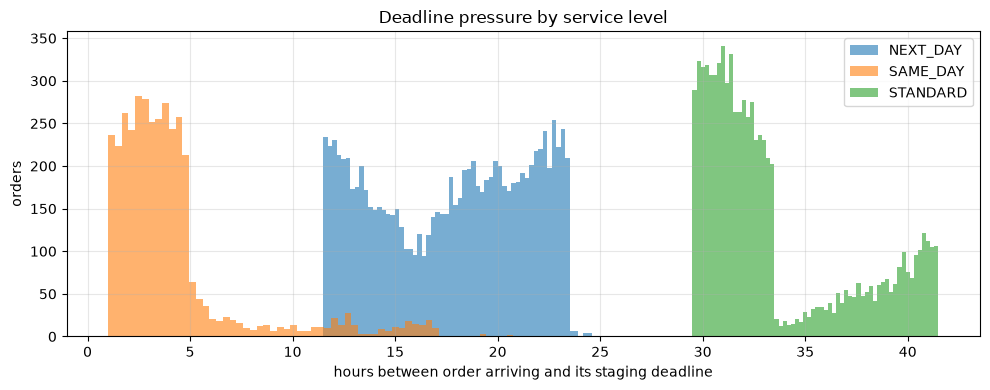

In [12]:
orders = tables['orders']
print(orders.groupby('service_level').agg(
    orders=('order_id', 'size'),
    mean_lines=('n_lines', 'mean'),
    mean_slack_h=('slack_at_creation_h', 'mean'),
    min_slack_h=('slack_at_creation_h', 'min'),
).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for level, grp in orders.groupby('service_level'):
    ax.hist(grp['slack_at_creation_h'], bins=60, alpha=0.6, label=level)
ax.set_xlabel('hours between order arriving and its staging deadline')
ax.set_ylabel('orders'); ax.legend(); ax.set_title('Deadline pressure by service level')
plt.tight_layout(); plt.show()

The three service levels occupy clearly separated bands, and none of these numbers was set by hand: a deadline is its truck's departure minus the staging buffer, so the distribution falls out of the departure timetable. A same-day order arriving just after a cut-off waits for the next truck, which is the long right tail on the orange distribution.